# Exercice 1.1 bis : EDA — **impact de la localisation sur le prix**

Variante du notebook E1 : même méthodologie d’analyse exploratoire, appliquée à un **sous-jeu centré sur la localisation** (quartier, zonage, conditions de proximité) et le prix de vente.


## Contexte

        Le dataset **Ames Housing** décrit des ventes de maisons à Ames (Iowa). Ici, on isole les variables qui décrivent **où** se situe le bien et **quel environnement** l’entoure, pour mesurer leur lien avec `SalePrice`.


# Variables étudiées (jeu réduit « localisation »)

| Colonne (pandas) | Rôle |
|------------------|------|
| `Neighborhood` | Quartier à Ames |
| `MSZoning` | Zonage (usage du sol) |
| `Condition1` | Proximité / condition 1 (route, voie ferrée, etc.) |
| `Condition2` | Proximité / condition 2 |
| `SalePrice` | Prix de vente (cible) |

```python
COLS_LOC = ["Neighborhood", "MSZoning", "Condition1", "Condition2", "SalePrice"]
```


## Objectifs d’apprentissage

- Structurer une EDA sur un sous-ensemble de variables métier (localisation).
- Décrire `SalePrice` et les distributions des modalités de localisation.
- Détecter des valeurs atypiques sur le prix (IQR, z-score modifié).
- Formuler des hypothèses sur l’effet du quartier et du zonage sur le prix.


### Section 1 — Imports et chargement

**À faire :**
- Charger `AmesHousing.csv`, harmoniser les noms de colonnes (suppression des espaces).
- Construire `df_loc = df[COLS_LOC].copy()`.
- Afficher les dimensions, les 5 premières lignes et les types.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

df = pd.read_csv("AmesHousing.csv")
df.columns = df.columns.str.replace(" ", "")

COLS_LOC = ["Neighborhood", "MSZoning", "Condition1", "Condition2", "SalePrice"]
df_loc = df[COLS_LOC].copy()

print(df_loc.shape)
print(df_loc.dtypes)
print(df_loc.head())


(2197, 5)
Neighborhood      str
MSZoning          str
Condition1        str
Condition2        str
SalePrice       int64
dtype: object
  Neighborhood MSZoning Condition1 Condition2  SalePrice
0      SawyerW       RL       Norm       Norm     159000
1      SawyerW       RL       Norm       Norm     271900
2       Timber       RL       Norm       Norm     137500
3      NridgHt       RL       Norm       Norm     248500
4      Gilbert       RL       RRAn       Norm     167000


### Section 2 — Aperçu général et qualité des données

**À faire :**
- Pour chaque colonne : nombre de valeurs manquantes et proportion.
- Vérifier les doublons complets sur les 5 colonnes.
- Les modalités rares (ex. quartiers) peuvent poser problème plus tard : notez les effectifs par `Neighborhood`.


In [4]:
miss = df_loc.isna().mean() * 100
print("Pourcentage de manquants par colonne :")
print(miss.round(2))

print("Doublons complets :", df_loc.duplicated().sum())

print("\nEffectifs par quartier (top 15) :")
print(df_loc["Neighborhood"].value_counts().head(15))


Pourcentage de manquants par colonne :
Neighborhood    0.0
MSZoning        0.0
Condition1      0.0
Condition2      0.0
SalePrice       0.0
dtype: float64
Doublons complets : 330

Effectifs par quartier (top 15) :
Neighborhood
NAmes      324
CollgCr    212
OldTown    182
Edwards    149
Somerst    149
NridgHt    135
Gilbert    127
NWAmes     105
Sawyer      99
SawyerW     89
Mitchel     89
Crawfor     76
BrkSide     72
IDOTRR      70
Timber      52
Name: count, dtype: int64


### Section 3 — Statistiques descriptives univariées

**À faire :**
- `describe()` sur `SalePrice` ; skewness et kurtosis.
- Tableaux de fréquences pour `Neighborhood`, `MSZoning`, `Condition1`, `Condition2` (tri par fréquence décroissante).


In [5]:
print(df_loc["SalePrice"].describe())
print("Skew SalePrice :", df_loc["SalePrice"].skew())
print("Kurtosis SalePrice :", df_loc["SalePrice"].kurtosis())

for col in ["Neighborhood", "MSZoning", "Condition1", "Condition2"]:
    print("\n---", col, "---")
    print(df_loc[col].value_counts())


count      2197.000000
mean     182376.851161
std       81168.157405
min       13100.000000
25%      130000.000000
50%      163500.000000
75%      215000.000000
max      755000.000000
Name: SalePrice, dtype: float64
Skew SalePrice : 1.77935955283085
Kurtosis SalePrice : 5.495252261791343

--- Neighborhood ---
Neighborhood
NAmes      324
CollgCr    212
OldTown    182
Edwards    149
Somerst    149
NridgHt    135
Gilbert    127
NWAmes     105
Sawyer      99
SawyerW     89
Mitchel     89
Crawfor     76
BrkSide     72
IDOTRR      70
Timber      52
NoRidge     52
StoneBr     36
SWISU       32
ClearCr     30
MeadowV     26
Blmngtn     24
BrDale      21
NPkVill     19
Veenker     15
Greens       6
Blueste      4
Landmrk      1
GrnHill      1
Name: count, dtype: int64

--- MSZoning ---
MSZoning
RL         1704
RM          340
FV          113
C (all)      19
RH           17
I (all)       2
A (agr)       2
Name: count, dtype: int64

--- Condition1 ---
Condition1
Norm      1894
Feedr      122
Arte

### Section 4 — Visualisations et symétrie du prix

**À faire :**
- Histogramme + KDE de `SalePrice` ; Q-Q plot (normalité grossière).
- Graphiques adaptés aux variables qualitatives : barres des effectifs pour le zonage et les conditions.
- Graphique montrant la **médiane de `SalePrice` par `Neighborhood`** (barres horizontales, triées).


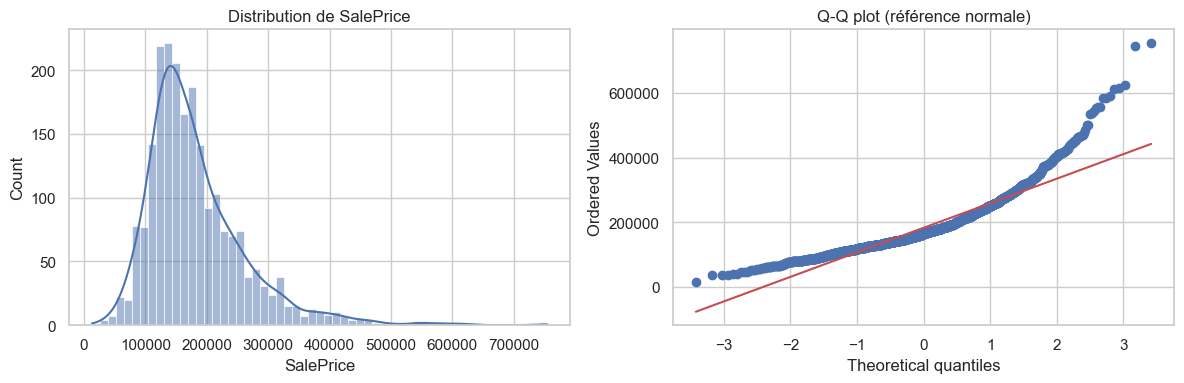

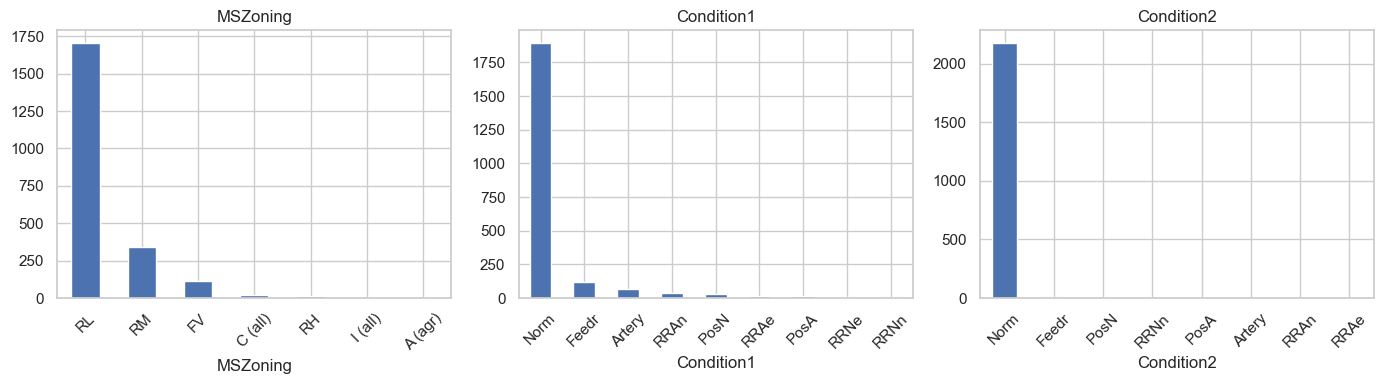

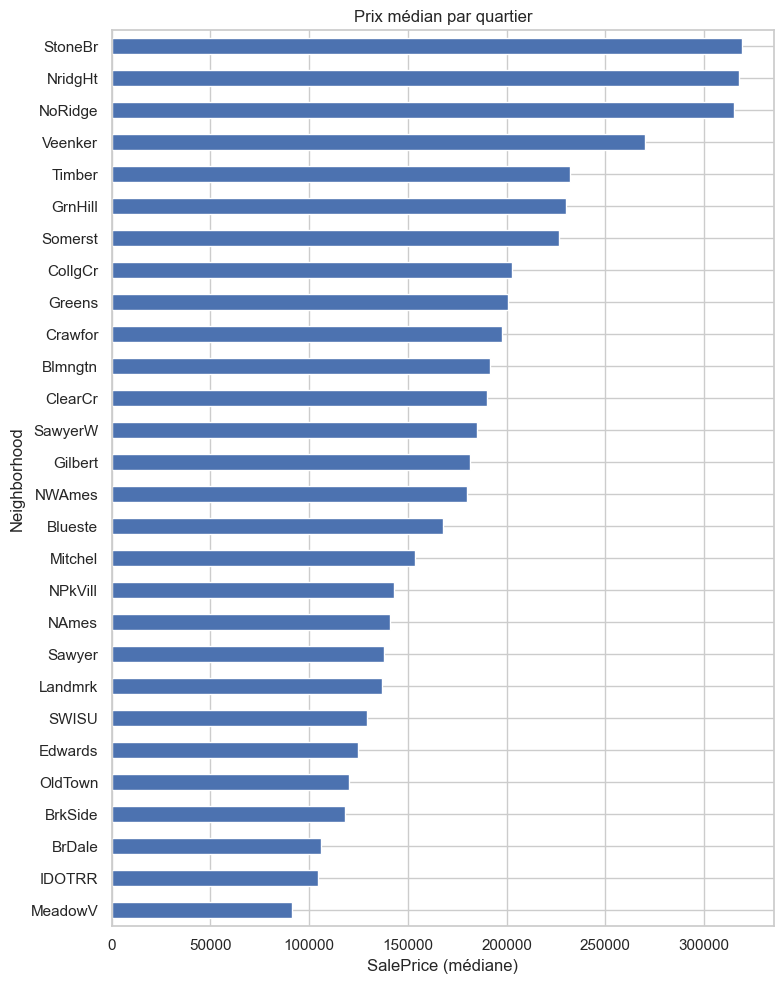

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_loc["SalePrice"], kde=True, ax=ax[0])
ax[0].set_title("Distribution de SalePrice")
stats.probplot(df_loc["SalePrice"], dist="norm", plot=ax[1])
ax[1].set_title("Q-Q plot (référence normale)")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["MSZoning", "Condition1", "Condition2"]):
    df_loc[col].value_counts().head(12).plot(kind="bar", ax=ax, rot=45)
    ax.set_title(col)
plt.tight_layout()
plt.show()

med_nbh = df_loc.groupby("Neighborhood")["SalePrice"].median().sort_values()
med_nbh.plot(kind="barh", figsize=(8, 10), title="Prix médian par quartier")
plt.xlabel("SalePrice (médiane)")
plt.tight_layout()
plt.show()


### Section 5 — Détection d’outliers sur le prix (IQR et z-score modifié)

**À faire :**
- Sur `SalePrice` global : seuils IQR (1,5 × IQR) et comptage des points extrêmes.
- z-score modifié (MAD) ou `scipy.stats.median_abs_deviation` — repérer les observations extrêmes.
- Optionnel : même logique par **groupe `Neighborhood`** (prix « anormal » par rapport au quartier).


In [7]:
s = df_loc["SalePrice"]
q1, q3 = s.quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
mask_iqr = (s < low) | (s > high)
print(f"IQR : bornes [{low:.0f}, {high:.0f}], outliers : {mask_iqr.sum()}")

med = s.median()
mad = stats.median_abs_deviation(s, scale="normal")
z_mod = 0.6745 * (s - med) / (mad if mad > 0 else np.nan)
mask_z = np.abs(z_mod) > 3.5
print(f"z modifié (>|3,5|) : {mask_z.sum()} observations")


IQR : bornes [2500, 342500], outliers : 97
z modifié (>|3,5|) : 22 observations


### Section 6 — Hypothèses métier (localisation)

**À rédiger en Markdown :**
- H1 : les **quartiers** diffèrent significativement en prix médian.
- H2 : le **zonage** `MSZoning` est associé à des niveaux de prix distincts.
- H3 : certaines **conditions de proximité** (`Condition1` / `Condition2`) sont liées à des prix plus bas (nuisances).

Indiquez comment vous pourriez tester ces hypothèses (tests, modèles) dans les prochains exercices.
